In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Steps confront

[]

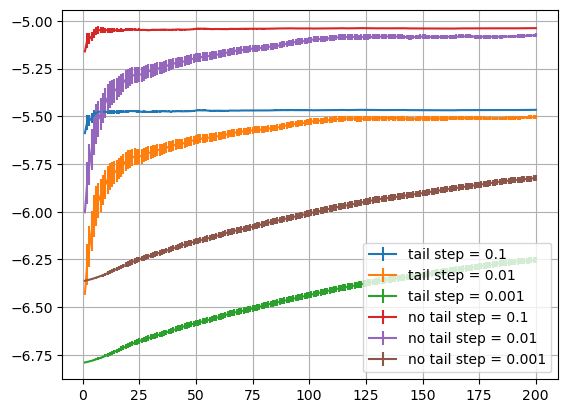

In [126]:
steps=[0.1, 0.01, 0.001]

# tail
for s in steps:
    df=pd.read_csv(f'OUTPUT/steps/tail/d{s}/potential_energy.dat', delimiter=r"\s+")
    plt.errorbar(df['#BLOCK:'], df['PE_AVE:'], yerr=df['ERROR:'], label=f'tail step = {s}')

# no tail
for s in steps:
    df=pd.read_csv(f'OUTPUT/steps/notail/d{s}/potential_energy.dat', delimiter=r"\s+")
    plt.errorbar(df['#BLOCK:'], df['PE_AVE:'], yerr=df['ERROR:'], label=f'no tail step = {s}')

plt.legend()
plt.grid()
plt.plot()

# Exercise 07.1 Tail correction

In [115]:
nt_path='OUTPUT/tail_correction_data/notail/'
acc_nt=pd.read_csv(nt_path+'acceptance.dat', delimiter=r"\s+")
U_nt=pd.read_csv(nt_path+'potential_energy.dat', delimiter=r"\s+")
P_nt=pd.read_csv(nt_path+'pressure.dat', delimiter=r"\s+")

In [116]:
yt_path='OUTPUT/tail_correction_data/tail/'
acc_yt=pd.read_csv(yt_path+'acceptance.dat', delimiter=r"\s+")
U_yt=pd.read_csv(yt_path+'potential_energy.dat', delimiter=r"\s+")
P_yt=pd.read_csv(yt_path+'pressure.dat', delimiter=r"\s+")

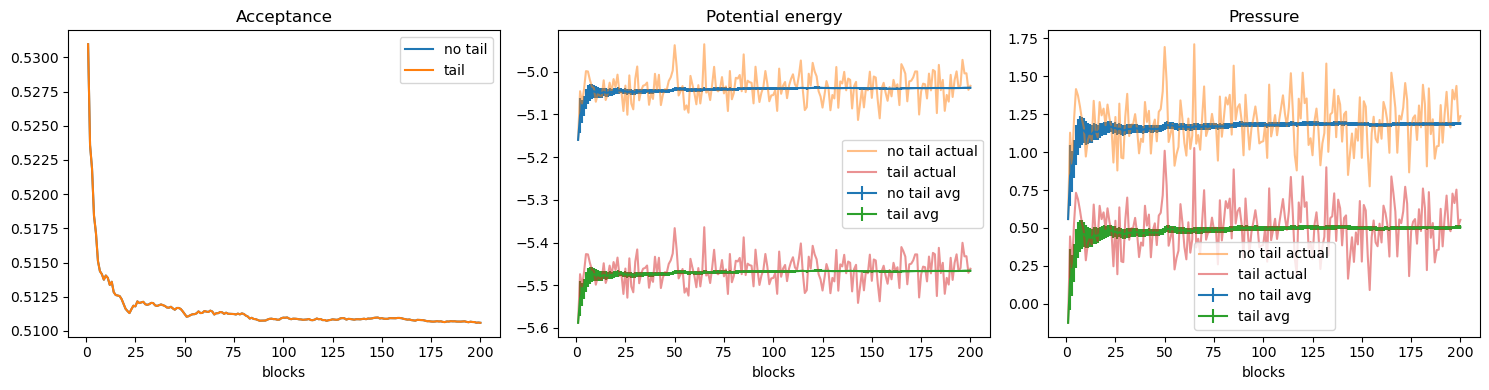

In [117]:
fig, ax= plt.subplots(1, 3, figsize=(15, 4))#, sharex=True)

ax[0].set_title('Acceptance')
ax[0].plot(acc_nt['#N_BLOCK:'], acc_nt['ACCEPTANCE:'], alpha=1, label='no tail')
ax[0].plot(acc_yt['#N_BLOCK:'], acc_yt['ACCEPTANCE:'], alpha=1, label='tail')


ax[1].set_title('Potential energy')
ax[1].errorbar(U_nt['#BLOCK:'], U_nt['PE_AVE:'], yerr=U_nt['ERROR:'], label='no tail avg')
ax[1].plot(U_nt['#BLOCK:'], U_nt['ACTUAL_PE:'], alpha=0.5, label='no tail actual')

ax[1].errorbar(U_yt['#BLOCK:'], U_yt['PE_AVE:'], yerr=U_yt['ERROR:'], label='tail avg')
ax[1].plot(U_yt['#BLOCK:'], U_yt['ACTUAL_PE:'], alpha=0.5, label='tail actual')

ax[2].set_title('Pressure')
ax[2].errorbar(P_nt['#BLOCK:'], P_nt['P_AVE:'], yerr=P_nt['ERROR:'], label='no tail avg')
ax[2].plot(P_nt['#BLOCK:'], P_nt['ACTUAL_P:'], alpha=0.5, label='no tail actual')

ax[2].errorbar(P_yt['#BLOCK:'], P_yt['P_AVE:'], yerr=P_yt['ERROR:'], label='tail avg')
ax[2].plot(P_yt['#BLOCK:'], P_yt['ACTUAL_P:'], alpha=0.5, label='tail actual')

for k in range(3):
    ax[k].set_xlabel('blocks')
    ax[k].legend()
plt.tight_layout()
plt.show()

# Exercise 07.2

## MC

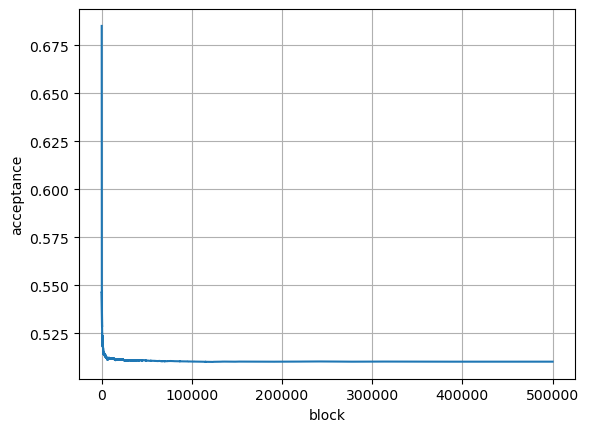

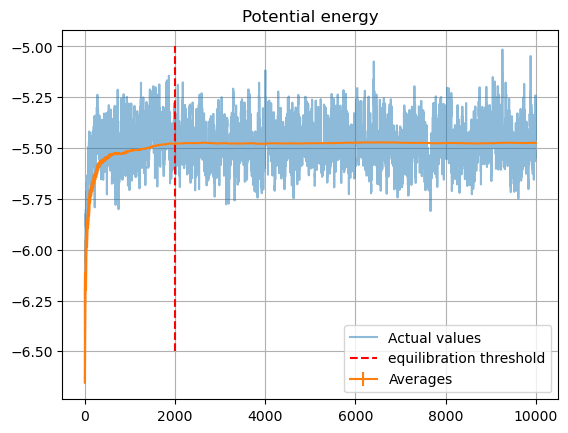

In [219]:
ac_mc=pd.read_csv('OUTPUT/MRT2/acceptance.dat', delimiter=r"\s+")

plt.plot(ac_mc['#N_BLOCK:'],  ac_mc['ACCEPTANCE:'])
plt.xlabel('block')
plt.ylabel('acceptance')
plt.grid()
plt.show()

U_mc=pd.read_csv('OUTPUT/MRT2/potential_energy.dat',  delimiter=r"\s+")
U_mc


plt.title('Potential energy')
plt.plot(U_mc['#BLOCK:'][:10000], U_mc['ACTUAL_PE:'][:10000], alpha=0.5, label='Actual values')

plt.errorbar(U_mc['#BLOCK:'][:10000], U_mc['PE_AVE:'][:10000], yerr=U_mc['ERROR:'][:10000], label='Averages')

plt.vlines(2000, -6.5, -5, color='r', ls='--', label='equilibration threshold')
plt.legend()
plt.grid()
plt.show()

## MD

In [25]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

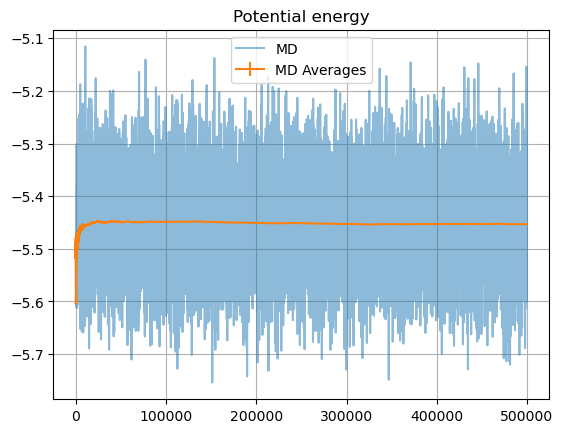

In [3]:

U_md=pd.read_csv('OUTPUT/potential_energy.dat',  delimiter=r"\s+")
U_md


plt.title('Potential energy')
plt.plot(U_md['#BLOCK:'][:], U_md['ACTUAL_PE:'][:], alpha=0.5, label='MD')

plt.errorbar(U_md['#BLOCK:'][:], U_md['PE_AVE:'][:], yerr=U_md['ERROR:'][:], label='MD Averages')


plt.legend()
plt.grid()
plt.show()

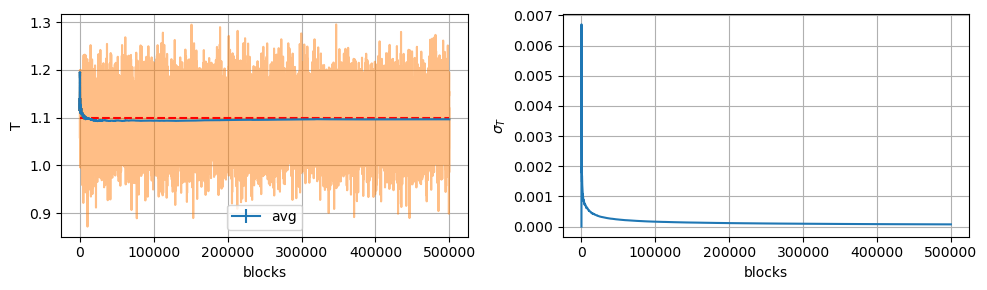

        #BLOCK:  ACTUAL_T:   T_AVE:    ERROR:
499999   500000    1.11944  1.09654  0.000074


In [8]:
temp_md = pd.read_csv('OUTPUT/temperature.dat', delimiter=r"\s+")

#plt.figure(figsize=(10, 5))
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].errorbar(
    temp_md['#BLOCK:'], temp_md['T_AVE:'],
    yerr=temp_md['ERROR:'], label='avg',
    #marker='*'
)

ax[0].plot(temp_md['#BLOCK:'], temp_md['ACTUAL_T:'], alpha=0.5)
ax[0].hlines(1.1, 0, 500000, ls='--', color='r')
ax[0].set_xlabel('blocks')
ax[0].set_ylabel('T')
ax[0].grid()
ax[0].legend()


ax[1].plot(temp_md['#BLOCK:'], temp_md['ERROR:'])
#plt.xlim([-100, 1000])
ax[1].set_xlabel('blocks')
ax[1].set_ylabel(r'$\sigma_T$')
ax[1].grid()

plt.tight_layout()
plt.show()

print(temp_md.loc[temp_md.index==len(temp_md)-1])

In [6]:
from tqdm import tqdm

In [118]:
def acorr1(x:pd.Series, ts) :

    ac=np.array([
        (np.sum([x[k]*x[k+t] for k in range(x.size-t)]) - ( np.sum(x[:x.size-t]) ) * (np.sum(x[t:])/(x.size-t)) )
        for t in tqdm(ts)
    ] )/ (x.var()*(x.size-t))
    
    return ac

In [143]:
def cor(x:pd.Series, ts):
    return [
        ( (x[:x.size-t]*x[t:]).sum()/(x.size-t) - (x[:x.size-t].mean())*(x[t:].mean()) ) / x.var()    
        for t in tqdm(ts)
    ]

In [204]:
s1=cor(U_md['ACTUAL_PE:'].values, range(0, 20000))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:40<00:00, 496.14it/s]


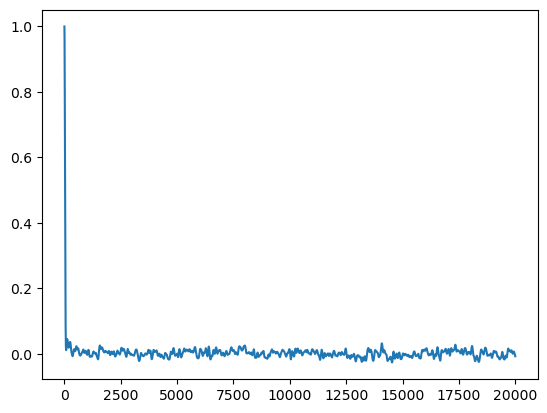

In [272]:
plt.plot(range(0,20000), s1)
#plt.yscale('log')
#plt.xlim([-10, 1000])

(-10.0, 100.0)

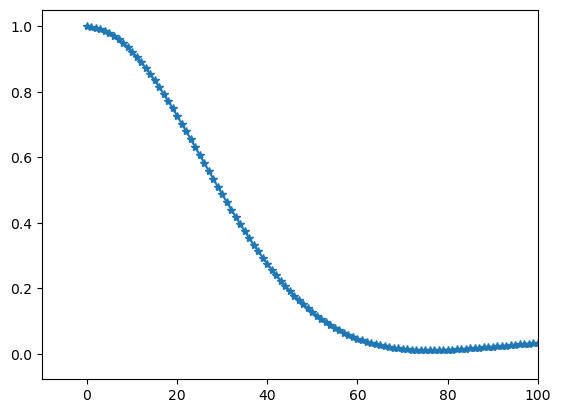

In [273]:
plt.plot(s1, '-*')
#plt.yscale('log')
plt.xlim([-10, 100])

(-10.0, 1000.0)

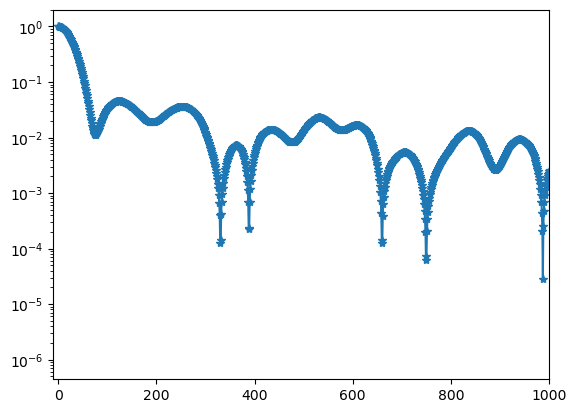

In [274]:
plt.plot(np.abs(s1), '-*')
plt.yscale('log')
plt.xlim([-10, 1000])

In [275]:
s1MC=cor(U_mc['ACTUAL_PE:'][2000:].values, range(0, 20000,10))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:04<00:00, 401.39it/s]


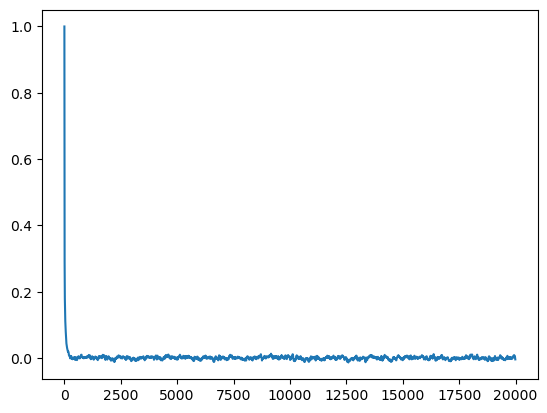

In [276]:
plt.plot(range(0, 20000,10), s1MC)


(-10.0, 1000.0)

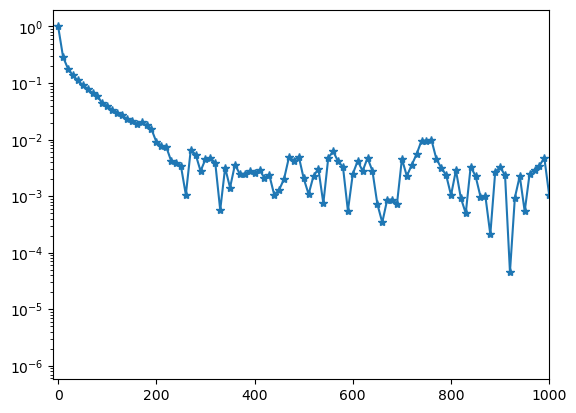

In [277]:
plt.plot(range(0, 20000,10), np.abs(s1MC), '-*')
plt.yscale('log')

plt.xlim([-10,1000])


# Exercise 07.3

In [299]:
gr_md=pd.read_csv('OUTPUT/gofr.dat', delimiter=r"\s+")

gr_md['block']=gr_md.index//100
gr_md

,#DISTANCE:,AVE_GOFR:,ERROR:,block
0,0.012825,0.000000,0.000000,0
1,0.038475,0.000000,0.000000,0
2,0.064124,0.000000,0.000000,0
3,0.089774,0.000000,0.000000,0
4,0.115423,0.000000,0.000000,0
...,...,...,...,...
19995,2.449540,0.911474,0.001103,199
19996,2.475190,0.901533,0.001123,199
19997,2.500840,0.415723,0.000638,199
19998,2.526490,0.000000,0.000000,199


Text(0, 0.5, 'g(r)')

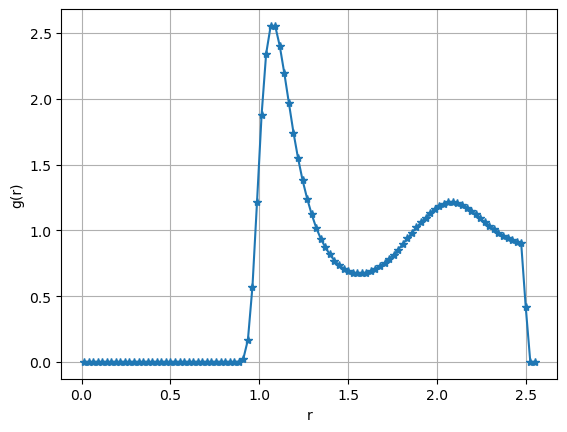

In [300]:
plt.plot(
    gr_md.loc[gr_md.block==gr_md.block.max()]['#DISTANCE:'], gr_md.loc[gr_md.block==gr_md.block.max()]['AVE_GOFR:'], marker='*'
)

plt.grid()

plt.xlabel('r')
plt.ylabel('g(r)')